# Boosting


- Ensemble technique that sequentially combines weak learners to form a strong learner
- Each Subsequent model focuses on correcting the errors made by previous 

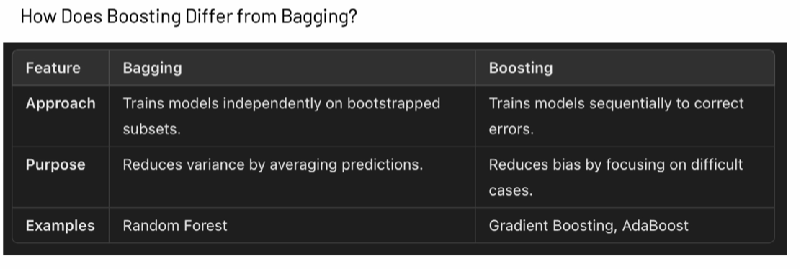


## Gradient Boosting
- Boosting algorithm that builds models sequentially by minimizing a loss function using gradient descent
- Iteratively adds weak learners (usually decision trees) to improve overall model performance

- #### How it works
  - **Initialize Model**: Start with a simple model, often predicting that mean of the target variable
  - **Compute Residuals:** calculate the difference between the actual and predicted values
  - **Fit Weak Learner:** Train a weak model to predict the residuals
  - **Update Prediction:** Add the prediction of the weak learned to the overall model
  - **Repeat:** Continue adding the weak learners until the desired number of iterations or a stopping criterion is reached


- #### Key Parameter in Gradient Boosting
  - **Learning Rate (learning_rate):**
    - Lower values improve model performance by reduceing overfitting but require more iterations 
    - Typical Range: 0.01 to 0.3
    - Determines the contribution of each weak learner
    - Smaller values reduce overfitting but require more iterations
  - **Number of Estimators (n_estimators)**
    - Represents the number of trees added to the ensemble
    - Larger value can improve performance but it risks overfitting
    - The numbers of weak learners (trees) added sequentially
    - Larger values improve learning but increase computation time
  - **Tree Depth (max_depth)**
    - Limits the complexity of indiviaul trees
    - Shallower trees generalize better but might underfit
  - **Regularization**
    -  Techniques like limiting tree depth or adding penalities to prevent overfitting

---

# Hands-On 
Train and Evaluate a Gradient Boosting modle on a dataset, tune key parameters and compare its performance with a random forest

In [26]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

# Load Dataset
data = load_breast_cancer()
X,y = data.data, data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
# Display dataset info
print(f"Features:{data.feature_names}")
print("-------------------")
print(f"Classes:{data.target_names}")

Features:['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
-------------------
Classes:['malignant' 'benign']


In [13]:
# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [14]:
# Predict 
y_pred_gb = gb_model.predict(X_test)

In [23]:
# Evaluate Performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy:{accuracy_gb:.4f}")
print("\n Classification Report \n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy:0.9561

 Classification Report 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [16]:
# Define Hyperparameter grid
param_grid = {
    'learning_rate':[0.01, 0.1, 0.2],
    'n_estimators':[50,100,200],
    'max_depth': [3,5,7]
}

In [19]:
# Perform Grid Search
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs =1
    
)

In [20]:
grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [22]:
# Display best parameters and score
print(f"Best Parameters:{grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy:{grid_search.best_score_:.5f}")

Best Parameters:{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validation Accuracy:0.96484


In [30]:
# To compare to random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
## Predict
y_pred_rf = rf_model.predict(X_test)

In [33]:
# Evaluate Perfomance
accuracy_rf = accuracy_score(y_test,y_pred_rf)
print(f"Random Forest Accuracy:{accuracy_rf:.4f}")

Random Forest Accuracy:0.9649
